In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [4]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

In [5]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
tanzania["Country"] = "Tanzania"
sudan["Country"] = "Sudan"
nigeria["Country"] = "Nigeria"

In [7]:
df = pd.concat([
    ethiopia,
    kenya,
    tanzania,
    sudan,
    nigeria
])

In [12]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
976,2017,246,25.58,28.52,23.51,5.01,0.79,74.90,4.86,7.05,101.03,15.13,Tanzania,2017-09-03,9
2653,2022,97,27.83,30.44,25.99,4.45,0.18,77.27,2.15,2.96,100.64,17.98,Tanzania,2022-04-07,4
1602,2019,142,26.27,27.91,25.28,2.63,20.61,86.39,5.33,6.11,100.92,18.38,Tanzania,2019-05-22,5
3101,2023,180,17.41,23.44,12.19,11.25,3.11,76.02,1.06,2.35,77.13,11.80,Ethiopia,2023-06-29,6
2438,2021,247,19.13,26.34,13.08,13.26,0.45,61.70,2.99,3.72,83.72,9.68,Kenya,2021-09-04,9


In [13]:
df["DATE"] = pd.to_datetime(df["DATE"])

df["YearMonth"] = df["DATE"].dt.to_period("M")

In [14]:
monthly_temp = df.groupby(
    ["YearMonth", "Country"]
)["T2M"].mean().reset_index()

monthly_temp["YearMonth"] = monthly_temp["YearMonth"].astype(str)

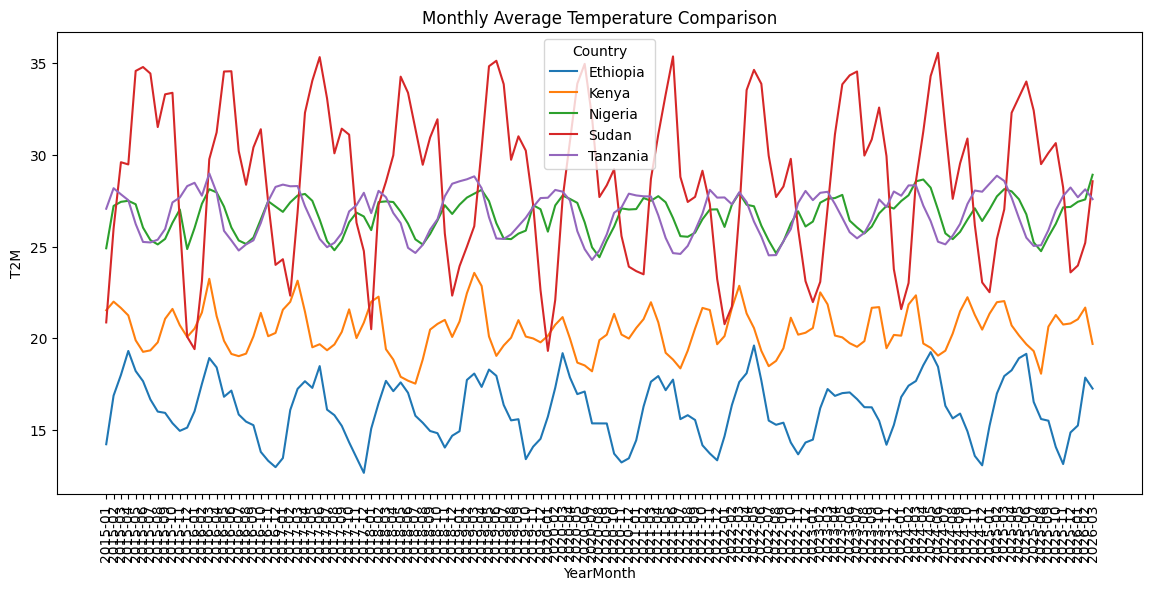

In [15]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_temp,
    x="YearMonth",
    y="T2M",
    hue="Country"
)

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature Comparison")
plt.show()

In [16]:
temp_summary = df.groupby("Country")["T2M"].agg([
    "mean",
    "median",
    "std"
])

temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


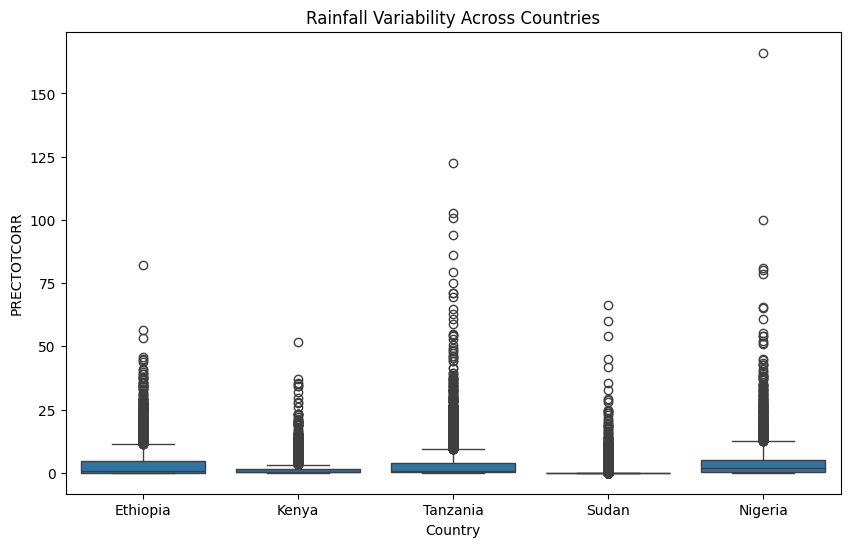

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Rainfall Variability Across Countries")
plt.show()

In [18]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg([
    "mean",
    "median",
    "std"
])

rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947
